In [4]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("heartPG.csv")
df

,Unnamed: 0,age,sex,rest_bp,chol,fbs,max_hr,exang,old_peak,slope,ca,disease
0,0,63,Male,145,233,1,150,0,2.3,3,0.0,0
1,1,67,Male,160,286,0,108,1,1.5,2,3.0,1
2,2,67,Male,120,229,0,129,1,2.6,2,2.0,1
3,3,37,Male,130,250,0,187,0,3.5,3,0.0,0
4,4,41,Female,130,204,0,172,0,1.4,1,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
298,298,45,Male,110,264,0,132,0,1.2,2,0.0,1
299,299,68,Male,144,193,1,141,0,3.4,2,2.0,1
300,300,57,Male,130,131,0,115,1,1.2,2,1.0,1
301,301,57,Female,130,236,0,174,0,0.0,2,1.0,1


In [6]:
X = df[["rest_bp", "chol"]]
y = df["disease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1902)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
scaler.mean_

array([132.03719008, 245.91322314])

In [9]:
scaler.scale_

array([17.29336868, 52.43985842])

In [10]:
logR = LogisticRegression()
logR.fit(X_train, y_train)
logR.coef_

array([[0.22848375, 0.09262178]])

In [11]:
logR.intercept_

array([-0.23559144])

In [12]:
df2 = pd.DataFrame({"predicted": logR.predict(X_test), "actual": y_test})

In [13]:
df2[df2["predicted"] - df2["actual"] != 0].shape[0]

29

In [14]:
df2.shape[0]

61

In [15]:
(df2.shape[0]-df2[df2["predicted"] - df2["actual"] != 0].shape[0])/df2.shape[0]

0.5245901639344263

In [16]:
df3 = pd.DataFrame({"actual": y_test, "predictedProbabilityB": logR.predict_proba(X_test)[:,0], "predictedProbabilityM": logR.predict_proba(X_test)[:,1], "predictedOutcome": logR.predict(X_test)})

In [17]:
b0 = logR.intercept_
b1 = logR.coef_[0][0]
b2 = logR.coef_[0][1]
x1 = X_test[0][0]
x2 = X_test[0][1]
z = b0 + b1 * x1 + b2 * x2
1/(1+np.exp(-z))

array([0.44217791])

In [18]:
logR.score(X_test, y_test)

0.5245901639344263

In [19]:
cm = metrics.confusion_matrix(y_test,logR.predict(X_test))

In [20]:
cm

array([[27,  2],
       [27,  5]])

In [21]:
print(metrics.classification_report(y_test, logR.predict(X_test)))

              precision    recall  f1-score   support

           0       0.50      0.93      0.65        29
           1       0.71      0.16      0.26        32

    accuracy                           0.52        61
   macro avg       0.61      0.54      0.45        61
weighted avg       0.61      0.52      0.44        61



<Axes: >

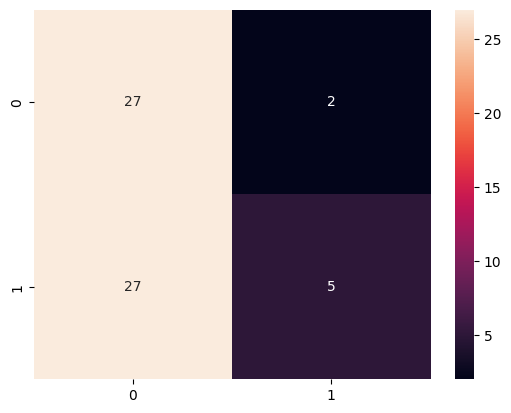

In [22]:
sns.heatmap(cm, annot = True)